# Learning in High Dimension

This notebook accompanies **Chapter 2, "Learning in High Dimensions"** of:

> M. M. Bronstein, J. Bruna, T. Cohen, and P. Veličković,  
> *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*.

The chapter is deliberately concise. Here we expand its main ideas computationally and mathematically, while avoiding repetition of material developed in the previous notebooks.

The central question is:

> **Why is learning difficult in high-dimensional spaces, and what kind of prior structure can make learning feasible?**

The two main themes are:

1. **Inductive bias via function regularity**
2. **The curse of dimensionality**

We will use simple experiments to make the scaling arguments concrete.

## 1. Supervised learning in a high-dimensional space

Suppose we observe

$$
\mathcal D = \{(x_i,y_i)\}_{i=1}^N,
\qquad
x_i\in\mathcal X,
\quad
y_i\in\mathcal Y,
$$

with samples drawn from an underlying distribution $P$.

In the simplest noiseless formulation used by the proto-book,

$$
y_i=f(x_i),
$$

where $f$ is unknown and we seek an approximation $\widetilde f$ from a hypothesis class $\mathcal F$.

A natural measure of performance is the population risk

$$
\mathcal R(\widetilde f)
=
\mathbb E_{x\sim P}
\left[
L(\widetilde f(x),f(x))
\right].
$$

For squared loss,

$$
L(y,\widehat y)
=
\frac12 |y-\widehat y|^2.
$$

The important issue is that interpolation of the training data is not, by itself, enough to determine how $\widetilde f$ behaves away from the observed points.

### A simple interpolation problem

Consider the one-dimensional target

$$
f(x)=\sin(2\pi x).
$$

We will deliberately use an interpolating polynomial with many degrees of freedom. This lets us distinguish:

- fitting the observations;
- controlling the behaviour between observations.

The latter is where a notion of **regularity** becomes important.

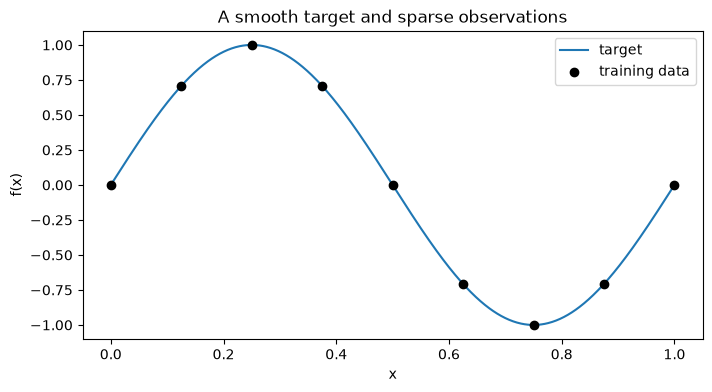

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a small training set from a smooth target function.
x_train = np.linspace(0, 1, 9)
y_train = np.sin(2 * np.pi * x_train)

# Dense grid used only for evaluating and visualising the functions.
x_plot = np.linspace(0, 1, 1000)
y_true = np.sin(2 * np.pi * x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, y_true, label="target")
plt.scatter(x_train, y_train, color="black", zorder=3, label="training data")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("A smooth target and sparse observations")
plt.legend()
plt.show()

## 2. Inductive bias via function regularity

An **inductive bias** is a preference for some hypotheses over others when the observed data alone do not determine a unique solution.

A useful way to impose such a preference is to introduce a complexity functional

$$
c:\mathcal F\to\mathbb R_{\geq 0}.
$$

Among all interpolating functions, we can select

$$
\widetilde f
\in
\operatorname*{arg\,min}_{g\in\mathcal F}
c(g)
\quad
\text{subject to}
\quad
g(x_i)=y_i.
$$

The data impose interpolation constraints; the complexity functional chooses among the many possible interpolants.

This is closely related to regularisation. In a penalised formulation one instead minimises

$$
\frac{1}{N}\sum_{i=1}^N
L(g(x_i),y_i)
+
\lambda c(g).
$$

The parameter $\lambda$ controls the trade-off between fitting the data and controlling complexity.

### Example: polynomial interpolation versus regularised regression

For a polynomial model

$$
g(x)=\sum_{k=0}^{m} w_k x^k,
$$

a high-degree polynomial can interpolate many observations exactly.

A regularised least-squares problem instead solves

$$
\min_w
\left\|
Xw-y
\right\|_2^2
+
\lambda\|w\|_2^2.
$$

The second term is a complexity penalty. It favours smaller parameter norms.

This is one concrete instance of the broader principle:

$$
\boxed{\text{data fit}+\text{complexity control}.}
$$

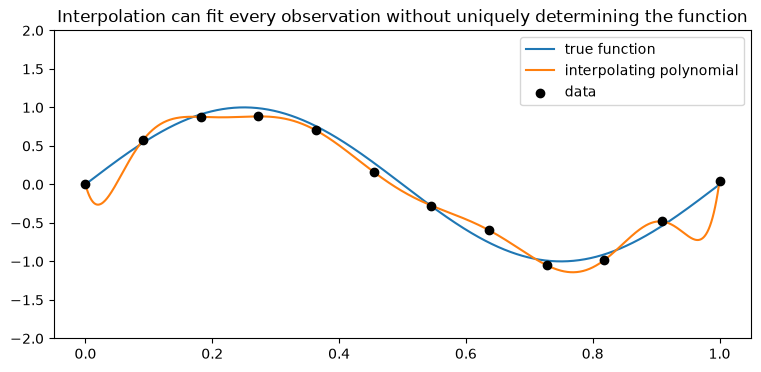

In [2]:
from numpy.polynomial import Polynomial

# Generate a noisy version of the same one-dimensional problem.
rng = np.random.default_rng(7)
x_train = np.linspace(0, 1, 12)
y_train = np.sin(2 * np.pi * x_train) + 0.12 * rng.normal(size=len(x_train))

x_plot = np.linspace(0, 1, 1000)
y_true = np.sin(2 * np.pi * x_plot)

# High-degree interpolation.
poly_interp = Polynomial.fit(x_train, y_train, deg=len(x_train) - 1)

plt.figure(figsize=(9, 4))
plt.plot(x_plot, y_true, label="true function")
plt.plot(x_plot, poly_interp(x_plot), label="interpolating polynomial")
plt.scatter(x_train, y_train, color="black", zorder=3, label="data")
plt.ylim(-2, 2)
plt.legend()
plt.title("Interpolation can fit every observation without uniquely determining the function")
plt.show()

### Weight decay as a complexity measure

For a linear model

$$
f_w(x)=w^\top x,
$$

the $L_2$ penalty

$$
c(w)=\|w\|_2^2
$$

is commonly called **weight decay** in neural-network optimisation.

The important conceptual point is not the particular penalty. Rather, the hypothesis class can contain many functions compatible with the training data, while the learning procedure introduces an additional preference over those functions.

The proto-book also points out that this preference need not always be explicit: optimisation itself can introduce **implicit regularisation**.

## 3. A small experiment with regularisation

We can see the effect of a quadratic penalty in a deliberately over-parameterised linear model.

For

$$
\min_w
\|Xw-y\|_2^2+\lambda\|w\|_2^2,
$$

the solution is

$$
w_\lambda
=
(X^\top X+\lambda I)^{-1}X^\top y,
$$

when the inverse exists.

This is the classical **ridge regression** solution.

In [3]:
# A small ridge-regression experiment.
rng = np.random.default_rng(4)

n_samples = 30
n_features = 80

X = rng.normal(size=(n_samples, n_features))
w_true = rng.normal(size=n_features)
y = X @ w_true + 0.5 * rng.normal(size=n_samples)

lambdas = [0.0, 0.1, 1.0, 10.0]

for lam in lambdas:
    if lam == 0:
        # Minimum-norm least-squares solution for the underdetermined system.
        w = np.linalg.pinv(X) @ y
    else:
        I = np.eye(n_features)
        w = np.linalg.solve(X.T @ X + lam * I, X.T @ y)

    residual = np.linalg.norm(X @ w - y)
    norm_w = np.linalg.norm(w)

    print(f"lambda={lam:>4}: training residual={residual:.3f}, ||w||_2={norm_w:.3f}")

lambda= 0.0: training residual=0.000, ||w||_2=4.457
lambda= 0.1: training residual=0.059, ||w||_2=4.449
lambda= 1.0: training residual=0.573, ||w||_2=4.382
lambda=10.0: training residual=4.747, ||w||_2=3.853


Notice the two competing effects:

- increasing $\lambda$ usually increases the training error;
- increasing $\lambda$ suppresses the parameter norm.

Thus regularisation changes which interpolating or approximately interpolating solution is preferred.

For a deeper statistical treatment of regularisation and Bayesian interpretations, Bishop's *Pattern Recognition and Machine Learning* is a useful complementary reference.

## 4. Lipschitz regularity

The proto-book uses a particularly clean notion of regularity to expose the curse of dimensionality.

A function

$$
f:\mathcal X\to\mathbb R
$$

is **1-Lipschitz** if

$$
|f(x)-f(x')|
\leq
\|x-x'\|
$$

for every $x,x'\in\mathcal X$.

More generally, $f$ is $L$-Lipschitz if

$$
|f(x)-f(x')|
\leq
L\|x-x'\|.
$$

The condition says that nearby inputs cannot produce arbitrarily different outputs.

It is therefore a genuine smoothness assumption—but, crucially, it is not strong enough to defeat high-dimensionality.

### A concrete Lipschitz example

The function

$$
f(x)=\|x\|_2
$$

is 1-Lipschitz because

$$
\big|\|x\|_2-\|x'\|_2\big|
\leq
\|x-x'\|_2.
$$

By contrast,

$$
f(x)=\|x\|_2^2
$$

is not globally Lipschitz on $\mathbb R^d$, since its gradient grows without bound.

This distinction is useful: Lipschitz regularity controls the rate at which a function can change, but does not restrict the function to a small finite-dimensional family.

In [4]:
# Empirically check the Lipschitz inequality for f(x) = ||x||_2.
rng = np.random.default_rng(0)

X = rng.normal(size=(1000, 5))
X_prime = rng.normal(size=(1000, 5))

f_X = np.linalg.norm(X, axis=1)
f_X_prime = np.linalg.norm(X_prime, axis=1)

left = np.abs(f_X - f_X_prime)
right = np.linalg.norm(X - X_prime, axis=1)

print("Largest value of left/right:", np.max(left / right))
print("The ratio should be at most 1, up to floating-point effects.")

Largest value of left/right: 0.8951835251849776
The ratio should be at most 1, up to floating-point effects.


## 5. Why dimension changes everything

The key geometric fact is the volume scaling of a $d$-dimensional region.

Consider the unit cube

$$
[0,1]^d.
$$

If we divide each coordinate direction into intervals of length $\epsilon$, then the number of cells is approximately

$$
\left(\frac{1}{\epsilon}\right)^d.
$$

For fixed $\epsilon<1$, this grows exponentially with $d$.

For example, with $\epsilon=0.1$:

$$
10^1,\quad
10^2,\quad
10^3,\quad
10^4,\ldots
$$

for dimensions $d=1,2,3,4,\ldots$.

This elementary counting argument already contains the essential intuition behind the curse of dimensionality.

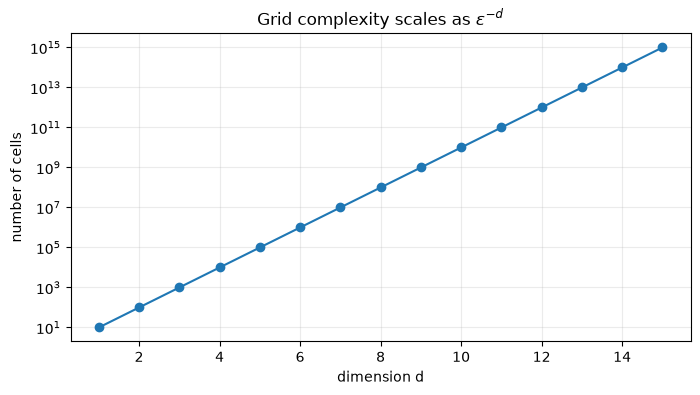

In [5]:
# Number of epsilon-sized cells in a d-dimensional unit cube.
epsilon = 0.1
dimensions = np.arange(1, 16)
n_cells = (1 / epsilon) ** dimensions

plt.figure(figsize=(8, 4))
plt.semilogy(dimensions, n_cells, marker="o")
plt.xlabel("dimension d")
plt.ylabel("number of cells")
plt.title(r"Grid complexity scales as $\epsilon^{-d}$")
plt.grid(True, alpha=0.25)
plt.show()

### Exercise

Change $\epsilon$ to $0.2$, $0.05$, and $0.01$.

Observe how changing the desired spatial resolution affects the dependence on dimension.

The important feature is not merely that the number becomes large. It is the **exponential dependence on $d$**.

## 6. The $\epsilon$-net viewpoint

A finite set $S\subset\mathcal X$ is an $\epsilon$-net for a domain if every point of the domain lies within distance $\epsilon$ of at least one point of $S$.

For a $d$-dimensional domain of bounded diameter, the size of an $\epsilon$-net generally scales like

$$
|S|
\sim
\epsilon^{-d}.
$$

This gives a useful geometric interpretation of the curse of dimensionality:

> To uniformly resolve a generic function in a high-dimensional domain, we need an exponentially large number of observations.

The proto-book expresses this through a maximum-discrepancy quantity for the Lipschitz class, with the characteristic scaling

$$
\kappa(d)\simeq N^{-1/d}.
$$

If we require

$$
\kappa(d)\lesssim\epsilon,
$$

then

$$
N=\Theta(\epsilon^{-d}).
$$

## 7. A nearest-neighbour experiment

Nearest-neighbour methods make the same phenomenon visually tangible.

Suppose we sample points uniformly from $[0,1]^d$. For a new point $x$, a local method needs training points sufficiently close to $x$.

As $d$ increases, a fixed-radius ball occupies a smaller and smaller fraction of the domain.

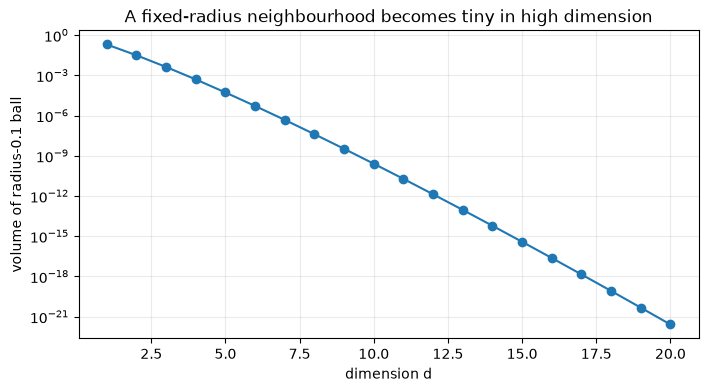

In [6]:
from math import pi, gamma

def unit_ball_volume(d, r):
    # Volume of a d-dimensional Euclidean ball of radius r.
    return (pi ** (d / 2) / gamma(d / 2 + 1)) * r ** d

radius = 0.1
dimensions = np.arange(1, 21)

fractions = np.array([
    unit_ball_volume(d, radius)
    for d in dimensions
])

plt.figure(figsize=(8, 4))
plt.semilogy(dimensions, fractions, marker="o")
plt.xlabel("dimension d")
plt.ylabel("volume of radius-0.1 ball")
plt.title("A fixed-radius neighbourhood becomes tiny in high dimension")
plt.grid(True, alpha=0.25)
plt.show()

For the unit cube, the ball volume is only an approximation to the fraction of the domain covered because balls near the boundary extend outside the cube. The experiment is intended to isolate the scaling

$$
\operatorname{Vol}(B_r^d)
=
\frac{\pi^{d/2}}{\Gamma(d/2+1)}r^d.
$$

The factor $r^d$ is the crucial part: local neighbourhoods shrink rapidly as dimension grows.

This is one reason why methods based on local interpolation or local neighbourhoods can become statistically inefficient in generic high-dimensional spaces.

## 8. Lipschitz functions and local bumps

The proto-book gives a particularly instructive construction.

Imagine placing a small Lipschitz "bump" around many separated locations in a $d$-dimensional domain. Each bump can independently take different signs while preserving the Lipschitz constraint.

If there are roughly

$$
2^d
$$

well-separated regions, then a learner may need information from a substantial fraction of those regions to determine the target function.

The important point is that **Lipschitz regularity still permits an enormous number of possible functions**.

Regularity alone has not removed the high-dimensional complexity.

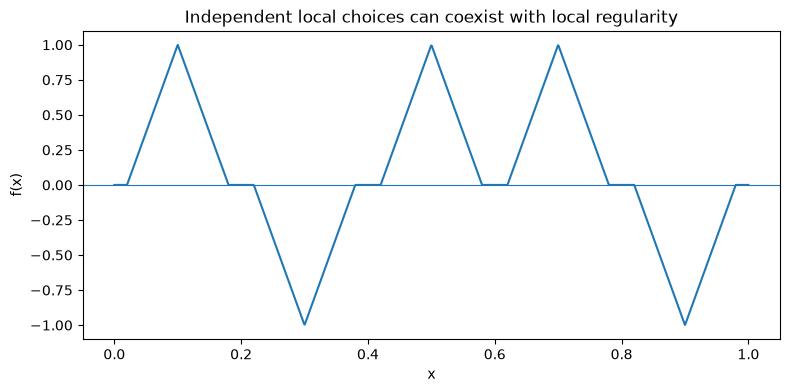

Signs used for the local bumps: [ 1 -1  1  1 -1]


In [7]:
# A simple 1D analogue of independent local bumps.
# The construction is pedagogical: in high dimensions the number
# of separated regions grows exponentially.

x = np.linspace(0, 1, 1000)

def tent(x, center, width):
    # Compactly supported triangular bump.
    return np.maximum(1 - np.abs(x - center) / width, 0)

centers = np.linspace(0.1, 0.9, 5)
rng = np.random.default_rng(12)
signs = rng.choice([-1, 1], size=len(centers))

f = sum(
    sign * tent(x, center, 0.08)
    for sign, center in zip(signs, centers)
)

plt.figure(figsize=(9, 4))
plt.plot(x, f)
plt.axhline(0, linewidth=0.8)
plt.title("Independent local choices can coexist with local regularity")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

print("Signs used for the local bumps:", signs)

The one-dimensional picture is easy to visualise. In $d$ dimensions, however, the number of separated regions that can be packed into a domain grows extremely rapidly.

This is the geometric source of the lower-bound intuition in the proto-book: a local smoothness condition does not sufficiently couple distant regions of a high-dimensional domain.

## 9. Beyond Lipschitz regularity: Sobolev smoothness

One might hope that stronger smoothness assumptions solve the problem.

A classical family of function spaces is given by **Sobolev spaces**. Very roughly, membership in a Sobolev space of order $s$ means that derivatives up to order $s$ have suitable integrability properties.

The relevant scaling highlighted by the proto-book is

$$
N
\sim
\epsilon^{-d/s}.
$$

Increasing $s$ improves the exponent, but the dependence on $d$ remains.

Thus smoothness helps, but generic smoothness does not eliminate the curse of dimensionality.

For fixed $s$,

$$
\epsilon^{-d/s}
$$

is still exponential in $d$.

### A simple scaling comparison

Suppose the desired approximation accuracy is

$$
\epsilon=10^{-2}.
$$

Compare

$$
N\sim\epsilon^{-d}
$$

with

$$
N\sim\epsilon^{-d/2}.
$$

The second assumption is substantially stronger, but both still grow exponentially with dimension.

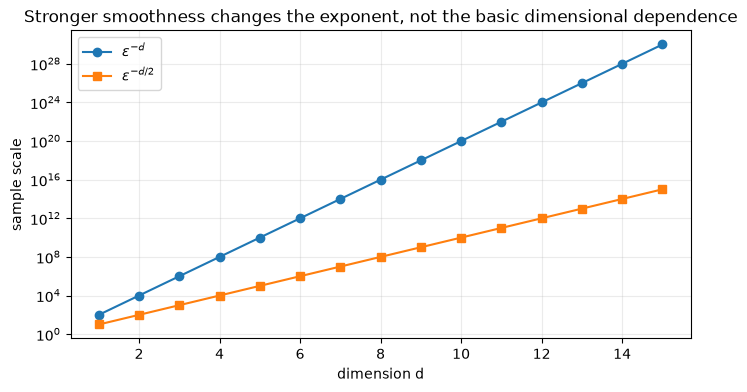

In [8]:
epsilon = 1e-2
dimensions = np.arange(1, 16)

lipschitz_scale = epsilon ** (-dimensions)
sobolev_scale = epsilon ** (-dimensions / 2)

plt.figure(figsize=(8, 4))
plt.semilogy(dimensions, lipschitz_scale, marker="o", label=r"$\epsilon^{-d}$")
plt.semilogy(dimensions, sobolev_scale, marker="s", label=r"$\epsilon^{-d/2}$")
plt.xlabel("dimension d")
plt.ylabel("sample scale")
plt.title("Stronger smoothness changes the exponent, not the basic dimensional dependence")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 10. Low-dimensional structure as an alternative

There is another possibility: perhaps the target does not genuinely depend on all $d$ coordinates.

Suppose

$$
f(x)
\approx
g(Ax),
$$

where

$$
A\in\mathbb R^{k\times d},
\qquad
k\ll d.
$$

Then the effective problem may be $k$-dimensional rather than $d$-dimensional.

The sample complexity can then depend on $k$ rather than $d$.

This is a powerful inductive bias, and it is related to ideas such as:

- dimensionality reduction;
- sufficient representations;
- projection pursuit;
- low-rank structure;
- sparse or structured dependence.

But it is also a strong assumption. A complicated physical system may depend on many degrees of freedom through nontrivial spatial correlations, even if the data admit useful low-dimensional representations for some tasks.

In [9]:
# A toy example: a function in d dimensions that actually depends
# on only two linear projections.

rng = np.random.default_rng(5)

d = 50
n = 1000

X = rng.normal(size=(n, d))

# Two hidden directions.
a1 = rng.normal(size=d)
a1 /= np.linalg.norm(a1)

a2 = rng.normal(size=d)
a2 /= np.linalg.norm(a2)

z1 = X @ a1
z2 = X @ a2

# The target depends only on (z1, z2), not on all 50 coordinates separately.
y = np.sin(z1) + 0.5 * z2**2

print("Ambient dimension:", d)
print("Effective projection dimension:", 2)
print("Correlation between the two hidden coordinates:",
      np.corrcoef(z1, z2)[0, 1])

Ambient dimension: 50
Effective projection dimension: 2
Correlation between the two hidden coordinates: -0.09286256980406142


The example is deliberately constructed so that the ambient space is

$$
\mathbb R^{50},
$$

but the target has the form

$$
f(x)=g(a_1^\top x,a_2^\top x).
$$

This is the type of assumption that can break the generic curse of dimensionality.

The central question for GDL is then:

> **What other kinds of structure can provide an effective reduction in complexity without assuming that the function depends only on a few global projections?**

Chapter 3 begins answering this question through geometric priors.

## 11. What Chapter 2 is really telling us

The chapter can be condensed into the following chain of ideas.

### Step 1: Large hypothesis classes are useful

Modern neural networks can represent extremely rich families of functions. In particular, universal approximation results show that expressivity alone need not be the bottleneck.

### Step 2: Expressivity does not determine generalisation

If many functions fit the observed samples, something else must distinguish useful solutions from arbitrary interpolants.

### Step 3: Regularity provides inductive bias

A complexity functional or regularisation mechanism can favour particular solutions.

### Step 4: Generic regularity is not enough in high dimension

For Lipschitz functions,

$$
N=\Theta(\epsilon^{-d}),
$$

and for Sobolev-type smoothness one obtains analogous exponential dependence on $d$.

### Step 5: We need structure adapted to the problem

Low-dimensional projections are one possibility, but real-world data often possess richer structure.

This motivates the geometric priors developed in Chapter 3.

## Summary

The main lesson of this notebook is not simply that high-dimensional learning is difficult.

It is more precise:

$$
\boxed{
\text{generic high-dimensional function classes are statistically too large.}
}
$$

Regularity assumptions such as Lipschitz continuity or Sobolev smoothness constrain the function class, but generic versions of these assumptions still lead to sample complexity that grows exponentially with dimension.

Therefore successful learning requires **additional structure**.

Chapter 3 develops one particularly important source of such structure: **geometric priors**.

## 12. Exercises

### Exercise 1 — Grid scaling

For $\epsilon=0.05$, compute the number of grid cells for

$$
d=1,2,\ldots,10.
$$

Plot the result on a logarithmic scale.

### Exercise 2 — Lipschitz functions

Verify numerically that

$$
f(x)=\|x\|_2
$$

is 1-Lipschitz for random pairs of points in $\mathbb R^{10}$.

### Exercise 3 — Regularisation

Modify the ridge-regression experiment and plot

$$
\|w_\lambda\|_2
$$

and the training error as functions of $\lambda$.

### Exercise 4 — Effective dimension

Construct a function on $\mathbb R^{20}$ that depends only on three linear projections. Try to recover those projections using a dimensionality-reduction method.

### Exercise 5 — Locality

Repeat the neighbourhood-volume experiment for several radii. How does the radius affect the dimensional scaling?

### Exercise 6 — Think about GDL

Chapter 2 identifies the need for additional structure but does not yet provide the geometric machinery.

What properties of images, graphs, point clouds, or meshes could reduce the effective complexity of the learning problem without requiring the target to depend on only a few global projections?

## References

1. **M. M. Bronstein, J. Bruna, T. Cohen, P. Veličković**,  
   *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*, arXiv:2104.13478, especially Chapter 2.

2. **C. M. Bishop**,  
   *Pattern Recognition and Machine Learning*, Springer, 2006.  
   See in particular §1.4, *The Curse of Dimensionality*, for a complementary treatment of high-dimensional spaces.

3. **C. M. Bishop**,  
   *Pattern Recognition and Machine Learning*, Springer, 2006.  
   The discussions of regularisation and Bayesian approaches in the chapters on linear models provide useful background for the role of complexity penalties.

4. **V. N. Vapnik**,  
   *Statistical Learning Theory*, Wiley, 1998.  
   A deeper mathematical treatment of generalisation, capacity, and statistical learning.

5. **A. B. Tsybakov**,  
   *Introduction to Nonparametric Estimation*, Springer, 2009.  
   A reference for minimax rates and the statistical theory underlying high-dimensional nonparametric estimation.